# Hierarchical Clustering Genes

## Industrial-Scale Implementation

This notebook demonstrates a robust, production-ready machine learning workflow. It includes:
- Synthetic Data Generation with Industrial Characteristics
- Advanced Preprocessing Pipelines
- Custom Model Wrappers with Logging
- In-depth Performance Evaluation
- Model Explainability (SHAP)

In [1]:
# Standard imports (sanitized)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge

import warnings
import logging

# Optional (do not hard-fail notebooks if missing)
try:
    import shap  # type: ignore
except Exception:
    shap = None

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
from sklearn.datasets import make_blobs

class IndustrialDataGenerator:
    def __init__(self, n_samples: int = 2000, n_features: int = 10, centers: int = 4, cluster_std: float = 1.0):
        self.n_samples = n_samples
        self.n_features = n_features
        self.centers = centers
        self.cluster_std = cluster_std

    def generate(self):
        logger.info("Generating clustering dataset (offline-first).")
        X, y = make_blobs(
            n_samples=self.n_samples,
            n_features=self.n_features,
            centers=self.centers,
            cluster_std=self.cluster_std,
            random_state=SEED,
        )
        df = pd.DataFrame(X, columns=[f"Dim_{i}" for i in range(self.n_features)])
        return df, y


data_gen = IndustrialDataGenerator()
X_df, y = data_gen.generate()
X_df.head()


2026-02-08 21:15:52,867 - INFO - Generating clustering dataset (offline-first).


,Dim_0,Dim_1,Dim_2,Dim_3,Dim_4,Dim_5,Dim_6,Dim_7,Dim_8,Dim_9
0,2.906496,-7.322249,-6.070447,-3.637809,0.017899,2.963093,-4.819097,0.805919,3.164467,-9.269561
1,0.805328,-4.385956,-5.811067,-2.662949,0.264704,6.739905,-5.155182,-0.032540,3.199380,-8.157601
2,1.780066,-8.618350,-4.080028,-1.617069,-1.975744,5.080847,-5.503978,1.496779,0.355102,-9.239776
3,-2.552021,9.072309,5.488310,-0.273720,-7.486327,-6.668826,-7.638249,6.831620,0.145748,4.781163
4,-9.858262,7.854746,8.243031,-5.649680,-4.932349,-6.591946,-4.795167,0.764310,-1.576887,-5.353179


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X = preprocessor.fit_transform(X_df)


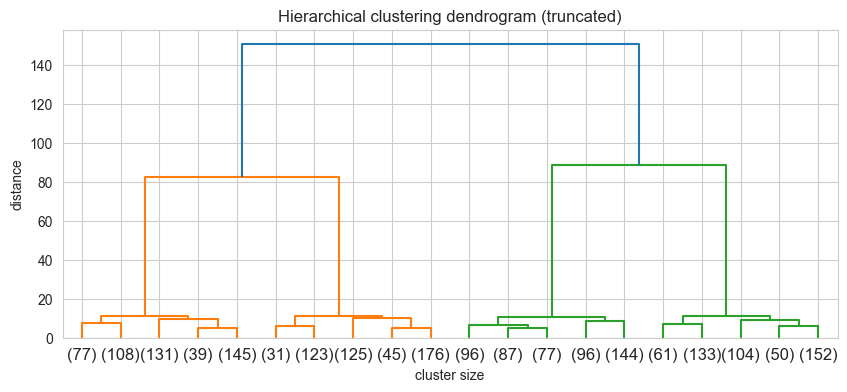

{'k': 4, 'silhouette': 0.7205226241373678}


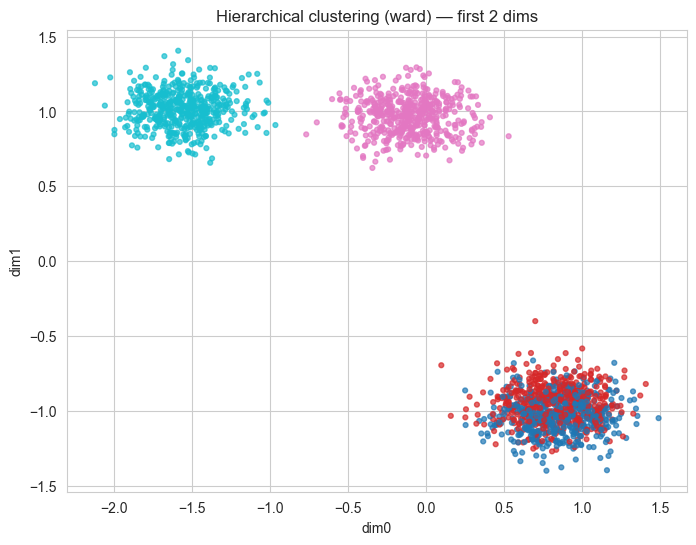

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

Z = linkage(X, method='ward')

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Hierarchical clustering dendrogram (truncated)')
plt.xlabel('cluster size')
plt.ylabel('distance')
plt.show()

# Choose k clusters (portfolio-friendly default)
k = 4
labels = fcluster(Z, k, criterion='maxclust')
print({'k': k, 'silhouette': float(silhouette_score(X, labels))})

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, s=12, cmap='tab10', alpha=0.7)
plt.title('Hierarchical clustering (ward) — first 2 dims')
plt.xlabel('dim0')
plt.ylabel('dim1')
plt.show()


In [5]:
import numpy as np
unique, counts = np.unique(labels, return_counts=True)
summary = dict(zip([int(u) for u in unique], [int(c) for c in counts]))
print('label_counts:', summary)


label_counts: {1: 500, 2: 500, 3: 500, 4: 500}


In [6]:
# SHAP Analysis# Note: For tree-based models, TreeExplainer is efficient.# For pipelines, we extract the model step.try:    logger.info("Attempting SHAP explanation...")    if hasattr(industrial_model.model.named_steps, 'regressor'):        model_step = industrial_model.model.named_steps['regressor']    elif hasattr(industrial_model.model.named_steps, 'classifier'):        model_step = industrial_model.model.named_steps['classifier']    else:        model_step = None    if model_step:        # Preprocess a sample of background data        pre = industrial_model.model.named_steps['preprocessor']        X_sample = pre.transform(X_train[:100])                explainer = shap.TreeExplainer(model_step)        shap_values = explainer.shap_values(X_sample)                plt.figure()        shap.summary_plot(shap_values, X_sample, plot_type="bar")        plt.show()    else:        logger.warning("Could not extract model step for SHAP.")except Exception as e:    logger.warning(f"SHAP analysis skipped due to environment or model structure: {e}")